# SMS Spam Classifier

## Objective

The objective of this project is to build a machine learning model capable of classifying SMS messages as **Spam** or **Ham**.

The project covers the complete NLP pipeline including:

- Data Cleaning
- Exploratory Data Analysis
- Text Preprocessing
- Feature Engineering
- Model Training
- Model Comparison
- Model Evaluation

### Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk


### Load Dataset

In [2]:
df = pd.read_csv("D:/NLP-Projects/Spam-Classifier/data/spam.csv", encoding="latin-1")


### Initial Exploration

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [5]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [6]:
df[df["Unnamed: 2"].notna()].shape

(50, 5)

The columns Unnamed: 2, Unnamed: 3, and Unnamed: 4 were created because some values in the v2 column contained commas. When the CSV file was read into a DataFrame, those commas were interpreted as column separators, causing the text to be split into additional columns. We can remove these extra columns.

### Data Cleaning 

The dataset contains three unnecessary columns which are removed.

Duplicate records are also removed.

In [7]:
# Dropping unnecessary columns

df = df.drop(columns =["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [8]:
# Renaming columns

df = df.rename(columns={"v1": "label", "v2": "message"})
df.head(2)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [9]:
df.isnull().sum()          # There are no missing values

label      0
message    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
# Removing Duplicates

df = df.drop_duplicates()
df.shape

(5169, 2)

### Exploratory Data Analysis (EDA)

#### Dataset Balance

In [12]:
# checking distribution of label
df["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

**Observation**: The dataset is imbalanced, with approximately 87.37% ham messages and 12.63% spam messages. Therefore, model evaluation should rely on precision, recall and F1-score in addition to accuracy.

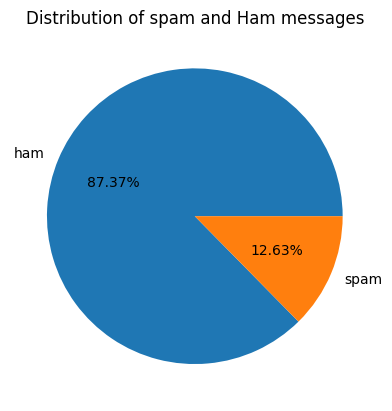

In [13]:
# visualizing through a pie chart

df["label"].value_counts().plot(kind="pie", autopct="%0.2f%%")
plt.ylabel("")
plt.title("Distribution of spam and Ham messages")
plt.show()

#### Feature Engineering

In [14]:
# Creating a column of Character Count
df["num_characters"] = df["message"].apply(len)

In [15]:
# Creating a column of word count
df["num_words"] = df["message"].apply(lambda x: len(x.split()))

In [16]:
# Creating a column for Sentence Count
import nltk
nltk.download("punkt")

df["num_sentences"] = df["message"].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\its0r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [17]:
df.head()

,label,message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,2
1,ham,Ok lar... Joking wif u oni...,29,6,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,ham,U dun say so early hor... U c already then say...,49,11,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,1


#### Statistical Analysis

In [18]:
# comparing if spam messages are generally longer than ham messages.

df.groupby("label")[["num_characters", "num_words", "num_sentences"]].mean()

,num_characters,num_words,num_sentences
label,,,
ham,70.459256,14.134632,1.820195
spam,137.891271,23.681470,2.970904


**Observation**: On average, spam messages are significantly longer than ham messages. Spam messages contain nearly twice as many characters, words, and sentences, suggesting that message length could be a useful feature for distinguishing spam from legitimate messages.

#### Visualizations

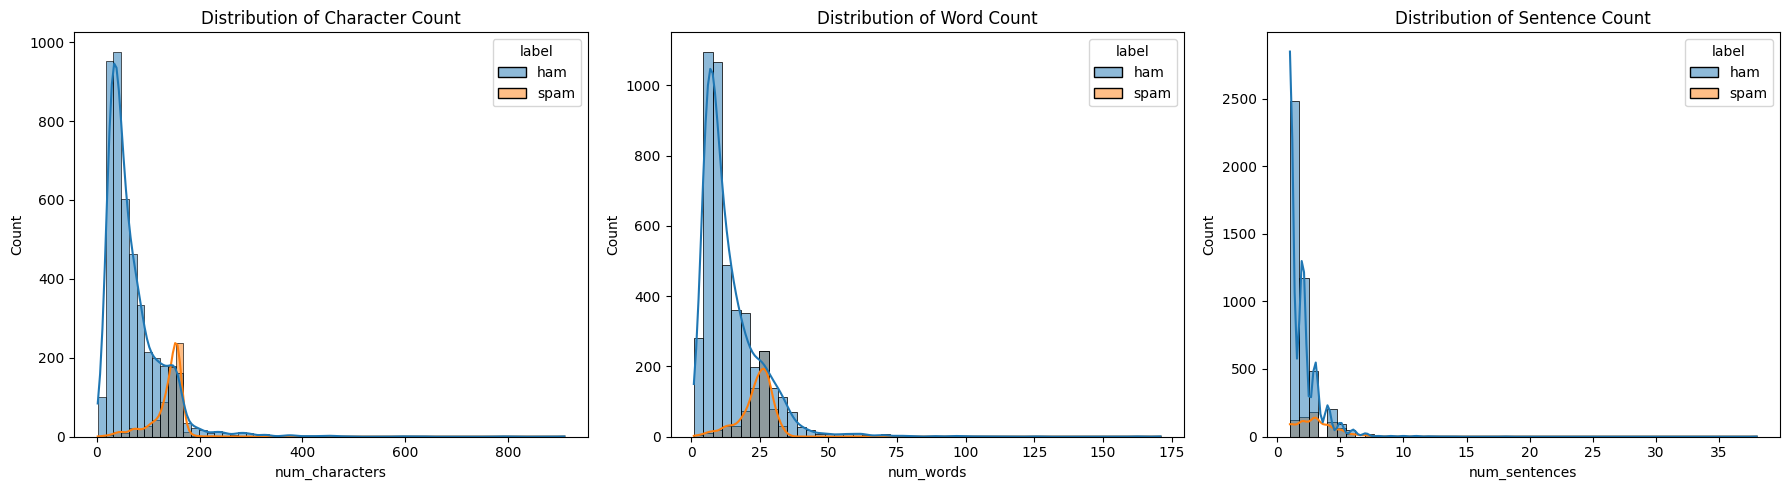

In [19]:
# Making histograms
import seaborn as sns
import matplotlib.pyplot as plt

# Creating subplots 
fig, axes = plt.subplots(1,3, figsize=(18,5))


# Histogram of Character count
def plot_histogram(coor, data, x, bins, title):
    sns.histplot(data = data, 
                 x = x,
                 hue = "label",
                 bins = bins,
                 kde = True,
                 ax= axes[coor]
                )
    axes[coor].set_title(title)


plot_histogram(0, df, "num_characters", 60, "Distribution of Character Count")
plot_histogram(1, df, "num_words", 50, "Distribution of Word Count")
plot_histogram(2, df, "num_sentences", 50, "Distribution of Sentence Count")

plt.tight_layout()
plt.show()

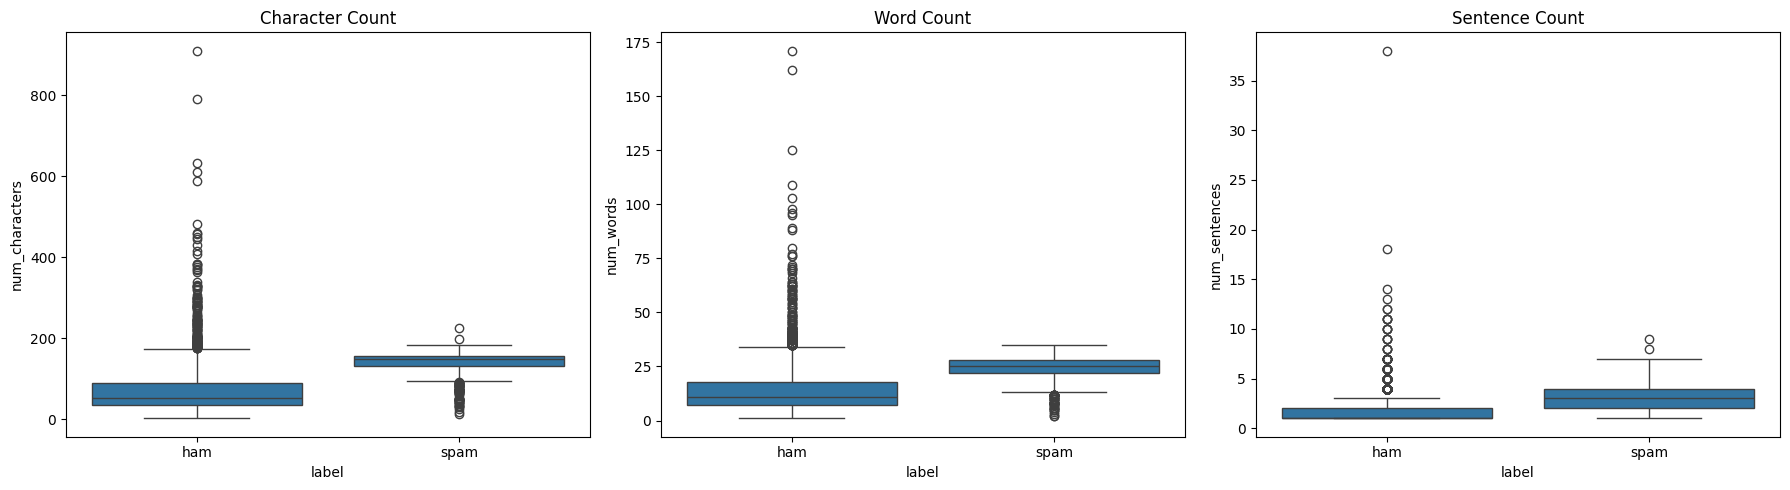

In [20]:
# Making Boxplots

fig, axes = plt.subplots(1,3,figsize=(18,5))

def plot_boxplot(y, coor, title):
    sns.boxplot(x="label", y=y, data=df, ax=axes[coor])
    axes[coor].set_title(title)

plot_boxplot("num_characters", 0, "Character Count")
plot_boxplot("num_words", 1, "Word Count")
plot_boxplot("num_sentences", 2, "Sentence Count")

plt.tight_layout()
plt.show()

**Observation:** From visualizations it is clear that the spam messages in general have high character, word and sentence counts.

### Text Preprocessing

Each SMS message undergoes the following preprocessing steps:

- Convert to lowercase
- Tokenization
- Remove non-alphanumeric characters
- Remove stopwords
- Apply Porter Stemming

In [22]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# importing the transform_text function from util.py
from utils import transform_text

### Apply Preprocessing

In [23]:
df["transformed_message"] = df["message"].apply(transform_text)

In [24]:
df[["message", "transformed_message"]].head()

,message,transformed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


### Word Clouds

In [25]:
from wordcloud import WordCloud

def make_wordcloud(label, title):
    text = " ".join(
        df[df["label"] == label]["transformed_message"]
    )
    
    wc = WordCloud(
        width = 800,
        height = 400,
        background_color = "white"
    )
    
    text_wc = wc.generate(text)
    
    plt.figure(figsize =(12,6))
    plt.imshow(text_wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

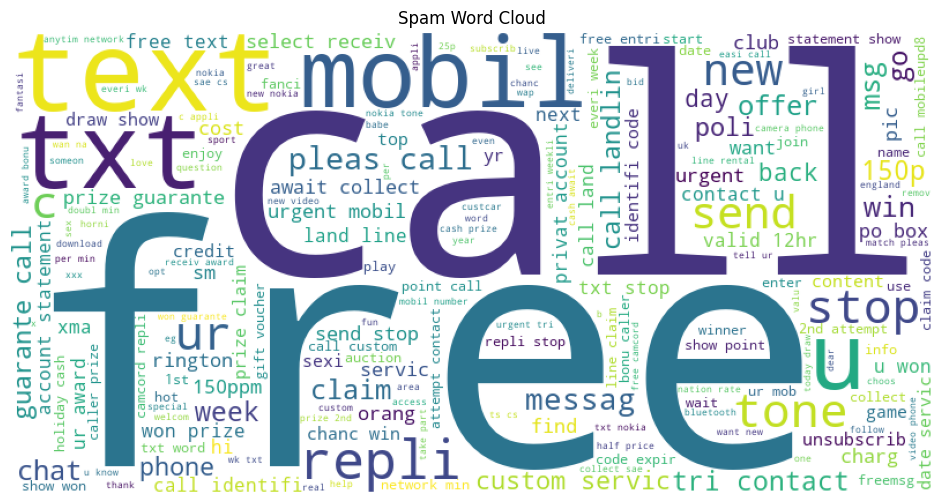

In [26]:
# Making word cloud for Spam messages
make_wordcloud("spam", "Spam Word Cloud")

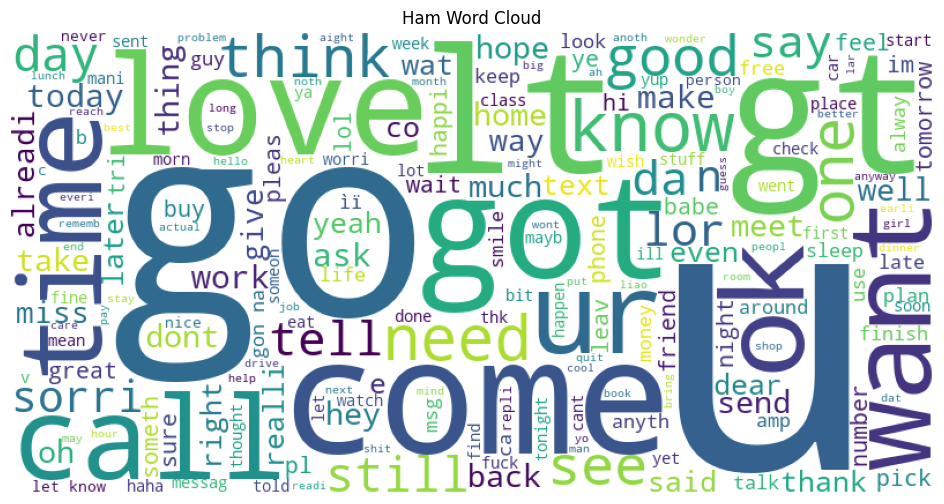

In [27]:
# Making word cloud fot Ham messages
make_wordcloud("ham", "Ham Word Cloud")

### Most Frequent Words

In [28]:
from collections import Counter

def plot_most_frequent_words(label, title):
    words = []
    
    for message in df[df["label"] == label]["transformed_message"]:
        for word in message.split():
            words.append(word)
    
    
    label_df = pd.DataFrame(
        Counter(words).most_common(30),
        columns=["word", "count"]
    )
    
    plt.figure(figsize=(12,6))
    
    sns.barplot(
        data=label_df,
        x="word",
        y="count"
    )
    
    plt.xticks(rotation = 90)
    plt.title(title)
    plt.show()

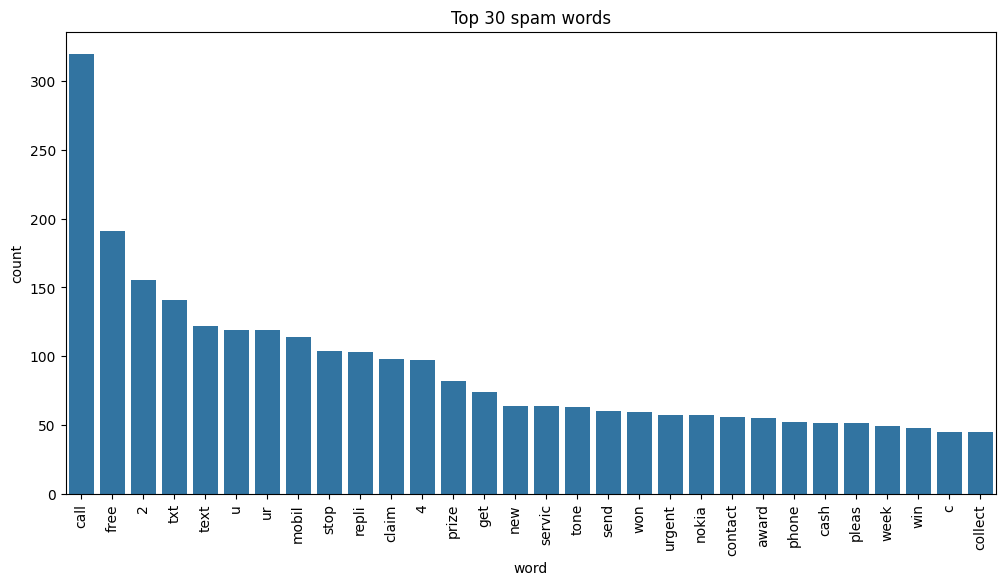

In [29]:
# Top 30 spam words
plot_most_frequent_words("spam", "Top 30 spam words")

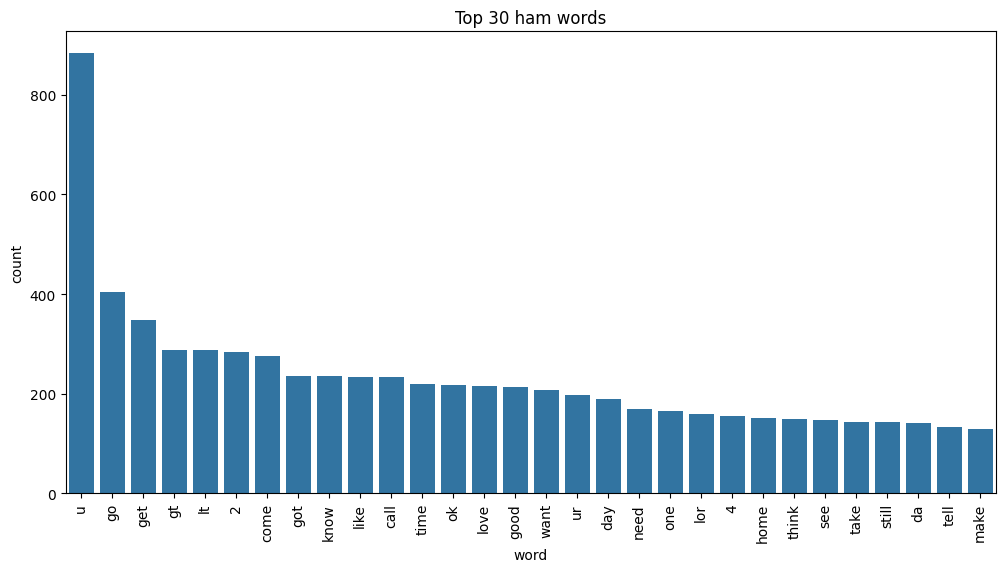

In [30]:
# Top 30 ham words
plot_most_frequent_words("ham", "Top 30 ham words")

**Observation:** The spam messages contain words such as free, win, claim, cash. On the other hand ham messages contain more converstaional words like home, come, love, ok. 
    
**This is a strong indication that Bag of Words and TF-IDF will be effective because they rely on word frequencies.**


### Model building

#### Label Encoding

In [31]:
# Encoding label 

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["label"])

In [32]:
df.head(2)

,label,message,num_characters,num_words,num_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni


#### Helper Functions

In [33]:
# function for train_test_split
from sklearn.model_selection import train_test_split

def split_data(X,y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = 0.2,
        random_state = 42
    )

    return X_train, X_test, y_train, y_test

In [34]:
# Evaluating performance metrics
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict (X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }



In [35]:
# Using different models and returning their performance metrics
def run_experiment(models, vectorizer, representation_name, X, y):

    results = list()
    
    X_train_text, X_test_text, y_train, y_test = split_data(X, y)

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)


    for name, model in models.items():
        
        metrics = evaluate_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

        metrics["Model"] = name
        metrics["Text_representation"] = representation_name

        results.append(metrics)

    return results


#### Models

In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Random Forest": RandomForestClassifier(random_state = 42)
}

### Model Training

Two text representation techniques are compared:
- Bag of Words
- TF-IDF

In [37]:
# Using Bag of words
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = df["transformed_message"]
y= df["label"]

results_bow = run_experiment(models, cv, "BoW", X, y)

In [38]:
# Using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = df["transformed_message"]
y = df["label"]

results_tfidf = run_experiment(models, tfidf, "TF-IDF", X, y)

### Results

In [39]:
results_df = results_bow + results_tfidf

results_df = pd.DataFrame(results_df)

In [40]:
results_df.sort_values(
    by = ["Accuracy","F1"],
    ascending = False
).reset_index(drop = True)

,Accuracy,Precision,Recall,F1,Model,Text_representation
0,0.983559,0.992308,0.889655,0.938182,Linear SVM,BoW
1,0.982592,0.977444,0.896552,0.935252,Linear SVM,TF-IDF
2,0.979691,0.949275,0.903448,0.925795,Naive bayes,BoW
3,0.977756,0.976562,0.862069,0.915751,Logistic Regression,BoW
4,0.966151,0.991071,0.765517,0.863813,Random Forest,TF-IDF
5,0.965184,0.990991,0.758621,0.859375,Random Forest,BoW
6,0.962282,0.990741,0.737931,0.845850,Naive bayes,TF-IDF
7,0.961315,0.948718,0.765517,0.847328,Logistic Regression,TF-IDF
8,0.950677,0.840580,0.800000,0.819788,Decision Tree,TF-IDF
9,0.950677,0.850746,0.786207,0.817204,Decision Tree,BoW


### Observations

- Linear SVM achieved the highest overall performance.
- Bag of Words slightly outperformed TF-IDF on this dataset.
- Tree-based models performed comparatively worse due to the sparse, high-dimensional feature space.

### Best Model

The best performing model was:
```
Vectorizer:
CountVectorizer
```

```
Classifier:
LinearSVC

### Training the best model

In [41]:
from sklearn.model_selection import train_test_split

X = df["transformed_message"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state = 42
)


In [42]:
from sklearn.feature_extraction.text import CountVectorizer

final_vectorizer = CountVectorizer()

In [43]:
X_train = final_vectorizer.fit_transform(X_train_text)
X_test = final_vectorizer.transform(X_test_text)

In [44]:
from sklearn.svm import LinearSVC

best_model = LinearSVC()
best_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [45]:
from sklearn.metrics import accuracy_score

pred = best_model.predict(X_test)

accuracy_score(y_test, pred)

0.9835589941972921

### Save the model

In [46]:
import pickle 

pickle.dump(
    best_model,
    open("D:/NLP-Projects/Spam-Classifier/models/spam_model.pkl","wb")
)

### Save the vectorizer

In [47]:

pickle.dump(
    final_vectorizer,
    open("D:/NLP-Projects/Spam-Classifier/models/vectorizer.pkl", "wb")
)

### Load them again

In [48]:
loaded_model = pickle.load(
    open("D:/NLP-Projects/Spam-Classifier/models/spam_model.pkl","rb")
)

In [49]:
loaded_vectorizer = pickle.load(
    open("D:/NLP-Projects/Spam-Classifier/models/vectorizer.pkl","rb")
)

In [50]:
def predict_spam(message):
    
    transformed = transform_text(message)
    
    vector = loaded_vectorizer.transform([transformed])

    prediction = loaded_model.predict(vector)[0]

    score = loaded_model.decision_function(vector)[0]

    label = "Spam" if prediction == 1 else "Ham"

    return {
        "Prediction": label,
        "Decision Score": round(float(score), 3)
    }

In [51]:
predict_spam(
    "URGENT! Congratulations! You've won $1000. Call now to claim your prize."
)

{'Prediction': 'Spam', 'Decision Score': 1.813}

In [52]:
predict_spam(
    "Hey, are we meeting tomorrow?"
)

{'Prediction': 'Ham', 'Decision Score': -1.697}

In [53]:
predict_spam(
    "URGENT! Claim your prize now!"
)

{'Prediction': 'Spam', 'Decision Score': 0.556}

### Conclusion

In this project, a complete classical NLP pipeline was implemented for SMS spam classification. The workflow included data cleaning, exploratory data analysis, text preprocessing, feature engineering using Bag of Words and TF-IDF, and evaluation of multiple machine learning algorithms.

Among all the evaluated combinations, Linear SVM with Bag of Words achieved the best performance, reaching an accuracy of approximately 98.36% with strong precision, recall, and F1-score. The experiments also demonstrated that the effectiveness of a classifier depends not only on the algorithm but also on the chosen text representation.

The final model and fitted vectorizer were serialized using pickle, making the solution reusable for deployment in future applications such as a web-based spam detection system.

### Future Improvements

- Compare with modern transformer-based models (e.g., BERT).
- Train on a larger and more recent spam dataset.
- Deploy the classifier as a web application using Streamlit.
- Perform hyperparameter tuning with GridSearchCV.